In [1]:
import sys
print(sys.executable)

e:\College\GradSchool\Year1\Semester2\CS4980\Project\venv\Scripts\python.exe


In [2]:
import mne
import numpy as np
import pandas
import matplotlib

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.autograd as autograd

# We are going to be looking at the first 3 EEG tests done in the following order:
# 1. Task 1 (open and close left or right fist) (1 minute)
# 2. Task 3 (open and close both fists or both feet) (1 minute)
# 3. Task 1 again after following different tasks (1 minute)
num_eeg_files = 3
edf_files = ['./Files/Set1/S001R03.edf', './Files/Set1/S001R05.edf', './Files/Set1/S001R07.edf']

# Introduction
This set utilizes A set of 64-channel EEGs from subjects who performed a series of motor/imagery tasks has been contributed to PhysioNet by the developers of the BCI2000 instrumentation system for brain-computer interface research.

Link: https://physionet.org/content/eegmmidb/1.0.0/

## Topic : Dependency Estimation in EEG Time-Series Data Using Mutual Information Neural Estimation (MINE)
![EEG Channels](../Images/Set1/64%20EEG%20Channels.png)

For this task, I plan to use an EEG dataset that contains multichannel recordings. A strong candidate is the PhysioNet EEG Motor Movement/Imagery Dataset. This dataset is publicly available and wellknown for its application in brain–computer interface research. It contains time-series recordings from multiple EEG channels, which makes it ideal for applying mutual information estimation to study inter-channel dependencies.

## Approach
    o Pre-process the EEG time-series data (filtering, segmentation, and normalization).
    o Implement a statistics network (as per MINE) using a deep learning framework to compute the lower-bound on mutual information.
    o Evaluate and compare the MINE estimator with classical methods (e.g., k-NN based MI estimators) on synthetic examples and on real EEG data.

## Framework 
I plan to implement the method in JupyterLab using a deeplearning library for building and training the neural network models.

## Timeline
    • Week 1–2: Data acquisition and pre-processing of EEG signals.
    • Week 3–4: Develop and test the MINE implementation on synthetic time-series data to validate the estimator.
    • Week 5–6: Apply the estimator on the EEG dataset, run experiments, and perform analysis of inter-channel dependencies.
    • Week 7: Compile results, prepare visualizations, and draft the final report.

I expect that the project will demonstrate that MINE can capture and quantify the nonlinear dependencies between EEG channels more effectively than traditional linear or nonparametric methods. The anticipated outcomes include:

    • A set of estimated mutual information values between pairs of EEG channels.
    • Insights into which channels exhibit strong dependencies (potentially indicating synchronized or functionally connected brain regions).
    • An evaluation of the robustness and scalability of the MINE approach for high-dimensional time-series data.
    • The findings will serve as a preliminary step toward leveraging mutual information for feature selection, network connectivity analysis, and potentially improved performance in downstream tasks like classification or brain–computer interface applications.

The findings will serve as a preliminary step toward leveraging mutual information for feature selection, network connectivity analysis, andpotentially improved performance in downstream tasks like classification or brain–computer interface applications.

# Data Preprocessing

To begin, we preprocess the EEG time-series data to prepare it for mutual information estimation using MINE.

We generate two types of batches for training:

- **Joint samples (P(X, Y))**: True paired observations from two EEG channels at the same time points. These preserve any natural dependency between signals.
- **Marginal samples (P(X) ⊗ P(Y))**: Synthetic pairs formed by randomly shuffling one of the channels. These remove dependency and simulate independence.

By training the neural network on both distributions, MINE learns to distinguish dependent from independent relationships, allowing it to estimate the **mutual information** (MI) between two EEG signals.
As per reference, Mutual Information is **exactly the quantity that tells you how different the joint (dependent) distribution is from the marginal (independent) one.** and is formally defined as **I(X;Y)=DKL​(P(X,Y)∥P(X)P(Y))**
So what we’re really doing is measuring a **distance (KL divergence)** between:
- The real paired data (dependent)
- The shuffled data (independent)

The MI estimate quantifies the degree of dependency between channels:  
- **Higher MI** → stronger dependency  
- **Lower MI** → weaker or no dependency


In [4]:
# This function is going to help us grab random samples from our batch information
# To start, we will randomly grab 300 samples
'''
data: Our array of (n_samples, 2) representing two random variables. Which are our pairs of EEG channel values
batch_size: How many samples we want to draw from each batch. Default value is going to be 300
sample_mode: What kind of sample we want to run. Typically either real samples ('joint'), or modified samples ('marginal')
'''
def sample_batch(data, batch_size = 300, sample_mode = 'joint'):
    # 'joint' runs a batch from our joint distribution P(X, Y)
    if sample_mode == 'joint':
        # Joint Sampling
        # We are taking full rows (x and y values) from the data
        index = np.random.choice(range(data.shape[0]), size = batch_size, replace = True)
        batch = data[index]

    # 'marginal' runs a batch from our product of marginals P(X) | P(Y)
    # This is basically our 'fake joint distribution' to help contrast with our main model
    else:
        # Our x values are going to come from the joint_index
        joint_index = np.random.choice(range(data.shape[0]), size = batch_size, replace = True)
        # Meanwhile, our y values are going to come from the marginal_index
        marginal_index = np.random.choice(range(data.shape[0]), size = batch_size, replace = True)
        batch = np.concatenate([data[joint_index][:, 0].reshape(-1, 1), data[marginal_index][:, 1].reshape(-1, 1)], axis = 1)
    return batch

In [5]:
# Load EEG files (example .edf file)
raw = []   # list to store raw EEG data
data_mine = []  # list to store numpy arrays of EEG signals (for MINE)
data_knn = []  # list to store numpy arrays of EEG signals (for kNN)

# One EEG file contains a list of 64 lists, each list referring to one of the electronodes placed on the head.
# This data was taken with 160 samples per second, or 1 sample every 6.25 MS.
# And on average of one or two minute baseline runs. Each list of samples should be roughly 160*(60 or 120) = 9600 - 19200 samples per list
for i in range(num_eeg_files):
    # We are going to read and store in 5 different files of information
    r = mne.io.read_raw_edf(edf_files[i])    
    # Storing our data
    raw.append(r)
    raw_data = r.get_data()  # shape: (64, n_times)

    # The EEG Channels we select will be based on a channel in the Frontal Lobe and one in the Parietal Lobe
    # The frontal lobe is responsible for decision making, while the parietal lobe is responsible for Sensory information like touch
    # By doing tests that involve closing your hands only when seeing an object go by, we want to see how they communicate with each other
    selected_channels = raw_data[[31, 48], :]  # Frontal Lobe: 32nd Electrode ; Parietal Lobe: 49th Electrode
    
    # Transpose to shape (n_times, 2)
    formatted_data = selected_channels.T

    # Append this entire trial's data as one array
    data_mine.append(formatted_data)

# Lastly, we are going to remove all data that is 0. Presumably information after the testing ended
data_mine = [trial[~np.any(trial == 0.0, axis=1)] for trial in data_mine]

# data_mine is now a list of 3 arrays: [(n₁, 2), (n₂, 2), (n₃, 2)]
data_knn = data_mine

Extracting EDF parameters from ./Files/S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ./Files/S001R05.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from ./Files/S001R07.edf...
Setting channel info structure...
Creating raw.info structure...


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting our seaborn extension for all of our scatter plots.
sns.set()

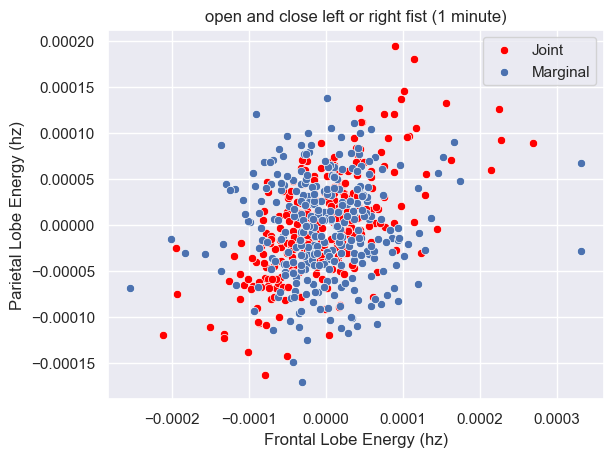

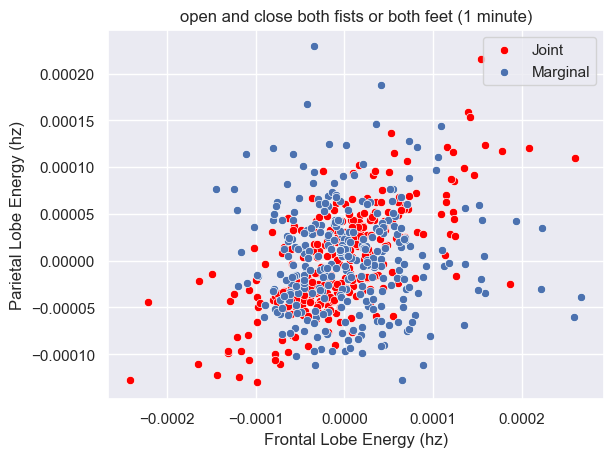

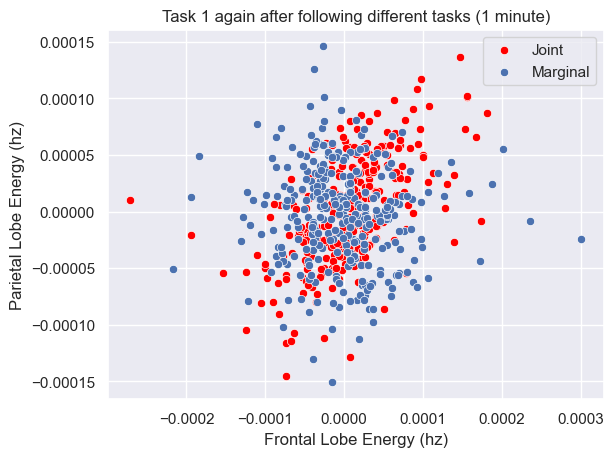

In [7]:
# This is going to help display our data between the 5 EEG files BEFORE we apply MINE to each database batch
# 1. Task 1 (open and close left or right fist) (1 minute)
# 2. Task 3 (open and close both fists or both feet) (1 minute)
# 3. Task 1 again after following different tasks (1 minute)
eeg_data = ["open and close left or right fist (1 minute)", "open and close both fists or both feet (1 minute)", "Task 1 again after following different tasks (1 minute)"]
# The batch size is going to be 300
for i in range(num_eeg_files):
    # First, we are getting our joint information
    # This is going to be the proper information from our EEG files. In other words, it will be more correlated
    joint_data = sample_batch(data_mine[i], batch_size = 300, sample_mode = 'joint')
    sns.scatterplot(x = joint_data[:, 0], y = joint_data[:, 1], color = 'red', label = 'Joint')

    # Next, we will be getting our marginal information
    # As stated, this information will be more independet, with differences between the y variables in the data
    marginal_data = sample_batch(data_mine[i], batch_size = 300, sample_mode = 'marginal')
    sns.scatterplot(x = marginal_data[:, 0], y = marginal_data[:, 1], label = 'Marginal')

    # This will be plotting our Joint and Marginal Data
    # With these plots, we will be able to see the difference between the two data sets
    plt.title(eeg_data[i])
    plt.legend(loc = 'upper right')
    plt.xlabel("Frontal Lobe Energy (hz)")
    plt.ylabel("Parietal Lobe Energy (hz)")
    plt.show()

# We should expect the information to be spread out a good amount
# After undergoing MINE, we hope to compute the lower-bound on the mutual information
# Doing so will then demonstate capturing and quantifying the nonlinear dependencies more effectively than other methods

# Defining MINE and Our Project

**MINE** (Mutual Information Neural Estimation) is a neural network-based approach for estimating mutual information (MI) between two random variables. Unlike traditional estimators, MINE can scale to high-dimensional data and capture complex, nonlinear dependencies.

MINE has been shown to outperform classical methods such as k-nearest neighbors (kNN) and kernel density estimators in various deep learning tasks—particularly in capturing dependencies between sensory inputs and learned representations.

However, MINE is still relatively new, especially in the context of EEG signal analysis, where most prior work relies on conventional techniques like Pearson correlation, coherence analysis, or nonparametric estimators like kNN. In our project, kNN will serve as the **baseline**.

## What Are We Trying to Do?

We aim to estimate the mutual information between two EEG signals (channels) by training a MINE model to distinguish:

- **Joint samples**: Correlated EEG channel pairs from the same time point.
- **Marginal samples**: Randomly paired channels from mismatched time points, simulating independence.

The goal is to show that **MINE can effectively quantify nonlinear dependencies** in EEG data—potentially outperforming kNN in scenarios where relationships between signals are not strictly linear.

## Challenges and Our Adjustments

MINE can struggle when data distributions have **high variance**, which is common in raw EEG recordings. To mitigate this:

- We normalize the EEG data across channels to reduce scale differences.
- We apply **moving average smoothing** to the MI estimates over training iterations, reducing noise and improving stability.
- We also *experiment* with histogram-based binning and scaling techniques to better condition the inputs for neural estimation.

By addressing these stability concerns, we hope to demonstrate that MINE is a viable tool for capturing complex EEG dependencies.


In [8]:
# Our main class for Mutual Information Neural Estimation
# It is going to be a subclass of PyTorch's Neural Network Model
class Mine(nn.Module):
    # Initialization
    '''
    self: Our MINE class
    input_size: Refers to how many inputs our model will take. For MINE, we only need 2 for X and Y
    hidden_size: How many units we want in the hidden layers of our network
    '''
    def __init__(self, input_size = 2, hidden_size = 100):
        # Initializing from out main Neural Network parent function
        super().__init__()

        # fc1, 2, 3 are going to be connected layers that take in input from our input_size and maps them to hidden_size units
        # By doing this, ...
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)

        # Normal...
        # Constant...
        nn.init.normal_(self.fc1.weight, std = 0.02)
        nn.init.constant_(self.fc1.bias, 0)
        nn.init.normal_(self.fc2.weight, std = 0.02)
        nn.init.constant_(self.fc2.bias, 0)
        nn.init.normal_(self.fc3.weight, std = 0.02)
        nn.init.constant_(self.fc3.bias, 0)

    # This function is going to trigger when we call our mine_net
    # It is used to calculate our joint and marginal dependencies
    '''
    self: Our MINE class
    input: Just our input data that will be passed through the model
    '''
    def forward(self, input):
        # Passing input through our first layer, applying ELU activation
        output = F.elu(self.fc1(input))
        # Same thing now in the second layer
        output = F.elu(self.fc2(output))
        # One more time through the final layer, which is going to become our MI Estimate
        output = self.fc3(output)
        return output

In [9]:
# This function is going to compute the lower bound of our mutual information using a neural network that learns T_theta
# This is based on the Donsker-Varadhan representation of the KL divergence
'''
joint: The joint distribution. This is a batch of true paired samples from the dataset (x, y). Basically our EEG signals from the channels => P_XZ
marginal: The marginal distribution. Our batch of paied samples where (x, y) are selected independently from different sets. Hence they're uncorrelated / unmatched => P_X P_Z
mine_net: The MINE Neural Network. We will use this to compute the estimated mutual information by passing the values through the layers
'''
def mutual_information(joint, marginal, mine_net):
    # This will pass our joint data through our MINE model, estimating the true Mutual Information
    # joint (T) = E_{P_{XZ}}[T_θ(x, z)]
    true_mi = mine_net(joint)
    
    # This will be passing our marginal data through our MINE model
    # We will estimate the mutual information from our independent pairs.
    # marginal (e^T) = E_{P_X ⊗ P_Z}[e^{T_θ(x, z)}]
    estimate_mi = torch.exp(mine_net(marginal))
    
    # This is computing the lower bound of our mutual information following the equation:
    # lowerbound ≈ E_{joint}[T] − log(E_{marginal}[e^T])
    lowerbound_mi = torch.clamp(torch.mean(true_mi) - torch.log(torch.mean(estimate_mi)), min=0.0)

    # Being returned is our lower bound, 
    return lowerbound_mi, true_mi, estimate_mi

# This function is be to help train our machine to MINE
# It works by adjusting our parameters through back propagation through the mutual information we computer and applying it to the loss function, optimizing the model
'''
batch: A tuple containing our joint and marginal data batches
mine_net: The MINE model that will be getting trained
mine_net_optim: The optimizer that we will use to update our model's parameters
movingaverage_estimate: The moving average of the exponential values of the network's output for the marginal data
ma_rate: The rate at which the moving average is updated (the default value will be 0.01)
'''
def learn_mine(batch, mine_net, mine_net_optim, movingaverage_estimate, ma_rate = 1e-8):
    # This will be getting our joint and marginal information from the batch
    joint, marginal = batch

    # Replace values in joint batch using histogram bin means
    def quantize_batch(batch_tensor, num_bins = 50):
        x_vals = batch_tensor[:, 0]   # .detach().numpy()
        y_vals = batch_tensor[:, 1]   # .detach().numpy()
    
        # Create bin edges and compute bin centers (means)
        x_edges = np.histogram_bin_edges(x_vals, bins=num_bins)
        y_edges = np.histogram_bin_edges(y_vals, bins=num_bins)
        x_means = (x_edges[:-1] + x_edges[1:]) / 2
        y_means = (y_edges[:-1] + y_edges[1:]) / 2
    
        # Get bin indices for each value
        x_bin_ids = np.clip(np.digitize(x_vals, x_edges) - 1, 0, num_bins - 1)
        y_bin_ids = np.clip(np.digitize(y_vals, y_edges) - 1, 0, num_bins - 1)
    
        # Replace values with their corresponding bin mean
        x_quantized = x_means[x_bin_ids]
        y_quantized = y_means[y_bin_ids]
    
        # Return as PyTorch tensor
        return torch.FloatTensor(np.column_stack([x_quantized, y_quantized]))

    # Quantize both joint and marginal batches
    joint = quantize_batch(joint)
    marginal = quantize_batch(marginal)
    
    # Here we are converting our joint and marginal batches to PyTorch tensors and moving them to our CPU
    # This will allow for better gradient tracking
    joint = torch.autograd.Variable(torch.FloatTensor(joint)).to('cpu')
    marginal = torch.autograd.Variable(torch.FloatTensor(marginal)).to('cpu')

    # Now here we will compute the lower bound of mutual information between our joint and marginal batches
    lowerbound_mi, true_mi, estimate_mi = mutual_information(joint, marginal, mine_net)
    movingaverage_estimate = (1-ma_rate)*movingaverage_estimate + ma_rate*torch.mean(estimate_mi)
    
    # Unbiasing use moving average
    # This means we will stabilize the training by averaging out the output of the marginal samples
    loss = -(torch.mean(true_mi) - (1/movingaverage_estimate.mean()).detach()*torch.mean(estimate_mi))

    # This optimizer is used to help zero out our gradients and update the model's parameters
    mine_net_optim.zero_grad()
    autograd.backward(loss)
    mine_net_optim.step()

    # Returning our lower bound and moving average in the end
    return lowerbound_mi, movingaverage_estimate

# Training: MINE

For training our MINE model, we use EEG data from **PhysioNet’s "EEG Motor Movement/Imagery Dataset"**, which includes over 1,300 one- to two-minute EEG recordings collected from 109 volunteers.

Each EEG sample is processed and then passed through our MINE model for approximately **2,500 training iterations**, where the model learns to distinguish between **joint** and **marginal** distributions:

## Training Objective

The goal is to observe **higher MI estimates on correlated data** and **lower values on uncorrelated (marginal) data**. These results would suggest that the model is detecting real dependencies between brain regions—potentially indicating functional connectivity or coordinated neural activity.


In [10]:
# This function is going to calculate the Moving Average of a given array (a)
# The Moving Average is our method used to smooth the data, helping reduce noise, and thus making things easier to identify.
# The reason being that our marginal term: log(E_{P_X ⊗ P_Z}[e^{T_θ(x, z)}]) an have very high variance, leading to training loss
'''
a: The input array for calculating the moving average
window_size: The number of elements we will be calculating the average of
'''
def calculate_moving_average(a, window_size = 160):
    return [np.mean(a[i:i + window_size]) for i in range(0, len(a) - window_size)]

In [11]:
# Now comes our main training module for MINE
# As expected, we will use this function to train our model on our given datasets
# We do this by going over several training iterations, where we generate batches of data and update our model via backpropagation
'''
data: Our (X, Y) data from the joint and marginal distributions
mine_net: Our MINE Neural Network model to be trained
mine_net_optim: Our optimizer that will update the weights during training
batch_size: However many batches we will be training our model with
iter_num: The number of iterations
log_freq: The frequency at which we will log our progress
'''
def train_MINE(data, set_num, mine_net, mine_net_optim, batch_size = 300, iter_num = 2500, log_freq = int(1e+3)):
    # Data is x or y
    result = list()
    ma_marginal = 1.
    num_bins = batch_size / 5
    
    # We will be looping and training across multiple epochs
    for i in range(iter_num):
        # First, we wanna get 2 batches. Using our Joint and Marginal distribution
        batch = sample_batch(data, batch_size), sample_batch(data, batch_size, sample_mode = 'marginal')

        # With our learn_mine function, we will compute the lower bound on our MI and then update the moving average
        # Doing this will compute the loss and update our model parameters
        lowerbound_mi, ma_marginal = learn_mine(batch, mine_net, mine_net_optim, ma_marginal)
        # Storing our results
        result.append(lowerbound_mi.detach().cpu().numpy())

    # Ultimately, result should be the list of mutual information lower bounds for each training iteration
    return result

# Training: kNN

To benchmark the performance of our MINE estimator, we compare it against a traditional nonparametric method: **k-Nearest Neighbor Mutual Information Estimation**. Specifically, we use the `mutual_info_regression` function from **scikit-learn**, which implements a kNN-based estimator suitable for continuous variables.

This comparison allows us to evaluate how well MINE captures **nonlinear dependencies** in contrast to a more conventional approach that estimates MI based on local distances between points in the feature space.

## Evaluation Goals

Through testing on both **synthetic data** and **real EEG signals**, we aim to evaluate the following:

- The **accuracy and sensitivity** of MINE vs. kNN across varying dependency structures.
- How well each method identifies **highly dependent EEG channel pairs**, potentially revealing functionally synchronized brain regions.
- The **robustness and scalability** of MINE on high-dimensional, noisy, and continuous time-series data compared to a kNN baseline.

By plotting the MI estimates across conditions, we expect to observe that **MINE produces more nuanced results**, particularly where nonlinear relationships exist that kNN cannot fully capture.


In [12]:
# Importing everything we need for the KNN Classifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_regression
import numpy as np

In [13]:
# Simulate training iterations for kNN MI Estimator
def train_KNN_MI(data, iter_num = 2500, batch_size = 300, sample_mode = 'joint'):
    result = []
    for _ in range(iter_num):
        # Getting our sample batch 
        joint, marginal = sample_batch(data, batch_size), sample_batch(data, batch_size, "marginal")
        # Separate X and Y from the batch
        if (sample_mode == 'joint'):
            x = joint[:, 0].reshape(-1, 1)
            y = joint[:, 1]
        else:
            x = marginal[:, 0].reshape(-1, 1)
            y = marginal[:, 1]

        # Estimate MI using sklearn's kNN-based estimator
        mi = mutual_info_regression(x, y, n_neighbors = 5, random_state = 1)
        result.append(np.mean(mi))
    return result

# Results: Synthetic Data

We begin our evaluation using **synthetic data** as a controlled baseline. This allows us to observe how both MINE and kNN estimators behave under known conditions with clearly defined relationships between variables.

These base cases use simple, mostly linear transformations of the input variable (e.g., \( f(x) = x, 2x, \sin(x), x^3 \)), allowing us to answer foundational questions such as:

- Does MINE produce MI estimates consistent with known dependency structures?
- How does kNN perform in low-noise, linear settings?
- Are both models sensitive to added noise and capable of capturing weakening dependencies?

Establishing this baseline is critical. Without it, we would have no reliable reference point for interpreting results on more complex and noisy EEG data later. In particular, we want to confirm that MINE produces **increasing MI values** as dependency increases and **approaches zero** as dependency fades (e.g., when noise is maximized).


In [14]:
x = np.random.uniform(low=-1,high=1,size=2500)
f1 = x
f2 = 2*x
f3 = np.sin(x)
f4 = x**3
eps = np.random.normal(size=2500)

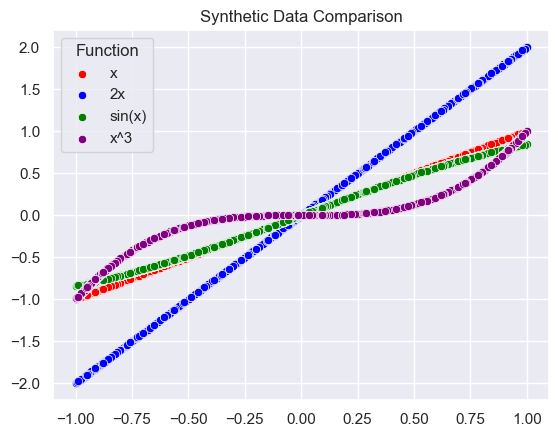

In [15]:
# Our 4 f values will resemble 4 different kinds of synthetic data
# f1 is linear 1-to-1 data
sns.scatterplot(x = x, y = f1, color = 'red', label='x')
# f2 is linear 2-to-1 data
sns.scatterplot(x = x, y = f2, color = 'blue', label='2x')
# f3 is the sin of our data
sns.scatterplot(x = x, y = f3, color = 'green', label='sin(x)')
# f4 is the our data cubed
sns.scatterplot(x = x, y = f4, color = 'purple', label='x^3')

plt.legend(title='Function')
plt.title('Synthetic Data Comparison')
plt.show()

### The `sigmas` represent different noise levels added to a synthetic function f(x)

- The higher the sigma, the more **noise** we add to the function `f`, i.e., `y = f(x) + sigma * eps`
- This makes the dependency between `x` and `y` weaker — because the signal is now masked by random variation
- As sigma increases, **Mutual Information (MI)** should **decrease**, ideally approaching 0 if the noise completely drowns out the signal

### Note:
- This is not about correlation going *away from* 0:
  - **Correlation and MI both decrease** as noise increases.
  - If the signal is perfectly linear (`f(x) = x`), the correlation is 1, and MI is high.
  - With more noise, correlation drops toward 0, and MI drops as well — though MI captures **nonlinear** dependencies too.


In [16]:
# Preparing our checks
sigmas = np.linspace(0, 0.9, 10)
fs = [f1, f2, f3, f4]
synth_labels = ['x', '2x', 'sin(x)', 'x^3']
print(sigmas)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


Text(0.5, 1.0, 'MINE MI Estimation on Synthetic Features with Noise')

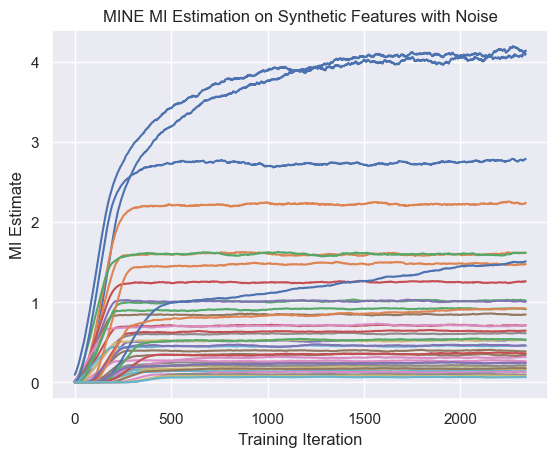

In [17]:
# Checking synthetic MI estimation with our MINE model
synthetic_MI_MINE = [[], [], [], []]
for fi, f in enumerate(fs):
    for sigma in sigmas:
        # Generating our synthetic training dataset
        # X represents our original value, while the Y will be a noisier version of f, making it more distorted
        data = np.concatenate([x.reshape(-1, 1), (f + sigma * eps).reshape(-1, 1)], axis=1)

        # Initializing and training now with our MINE model
        mine_net = Mine().to('cpu')
        mine_net_optim = optim.Adam(mine_net.parameters(), lr=1e-3)
        result = train_MINE(data, -1, mine_net, mine_net_optim)

        # Calculating the moving average of our result before appending it
        result_ma = calculate_moving_average(result)
        synthetic_MI_MINE[fi].append(result_ma[-1])
        # print(str(sigma) + ', ' + str(fi) +' : ' + str(final_result[-1]))
        plt.plot(range(len(result_ma)), result_ma)

# What should we expect from our graph?
# X is going to display all of our training iterations over time
# Y is going to display the MI Estimate. This is the correlation between X and f(X) + noise
plt.xlabel("Training Iteration")
plt.ylabel("MI Estimate")
plt.title("MINE MI Estimation on Synthetic Features with Noise")

# The higher the values, the stronger the MI
# Where as the lower the values, the more difficult it is to detect a signal or connection

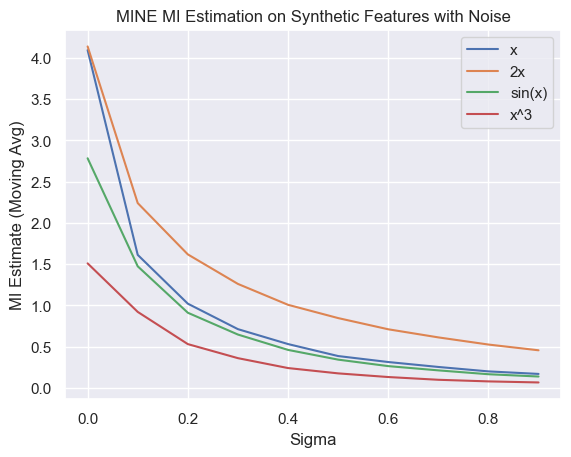

In [18]:
for fi, f in enumerate(fs):
    plt.plot(sigmas, synthetic_MI_MINE[fi], label = synth_labels[fi])

plt.xlabel("Sigma")
plt.ylabel("MI Estimate (Moving Avg)")
plt.title("MINE MI Estimation on Synthetic Features with Noise")
plt.legend()
plt.show()

In [ ]:
# Next, we will do the same thing with our kNN Model
synthetic_MI_KNN = [[], [], [], []]
for sigma in sigmas:
    for fi, f in enumerate(fs):
        # Create synthetic dataset with noise
        data = np.concatenate([x.reshape(-1, 1), (f + sigma * eps).reshape(-1, 1)], axis=1)

        # Train kNN-based MI estimator on synthetic data
        result = train_KNN_MI(data, iter_num=int(5e+3), batch_size=300)
        result_ma = calculate_moving_average(result)

        # Store last value of the moving average
        synthetic_MI_KNN[fi].append(result_ma[-1])

        # Plotting the MI progression for this sigma/feature
        plt.plot(range(len(result_ma)), result_ma)

# What should we expect from our graph?
# X is going to display all of our training iterations over time
# Y is going to display the MI Estimate. This is the correlation between X and f(X) + noise
plt.xlabel("Training Iteration")
plt.ylabel("MI Estimate (Moving Avg)")
plt.title("kNN MI Estimation on Synthetic Features with Noise")
plt.show()

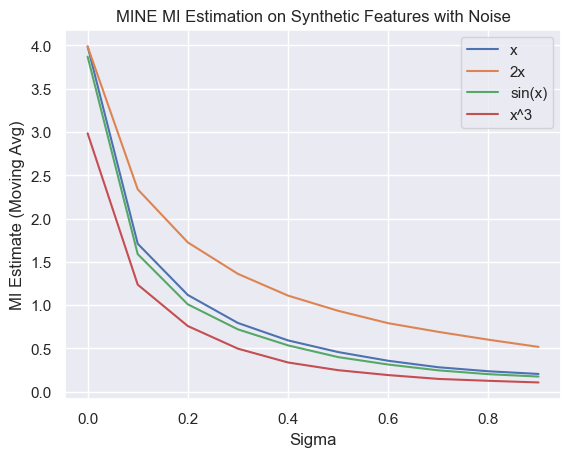

In [ ]:
# Graphing out all of our final points
for fi, f in enumerate(fs):
    plt.plot(sigmas, synthetic_MI_KNN[fi], label = synth_labels[fi])

plt.xlabel("Sigma")
plt.ylabel("MI Estimate (Moving Avg)")
plt.title("MINE MI Estimation on Synthetic Features with Noise")
plt.legend()
plt.show()

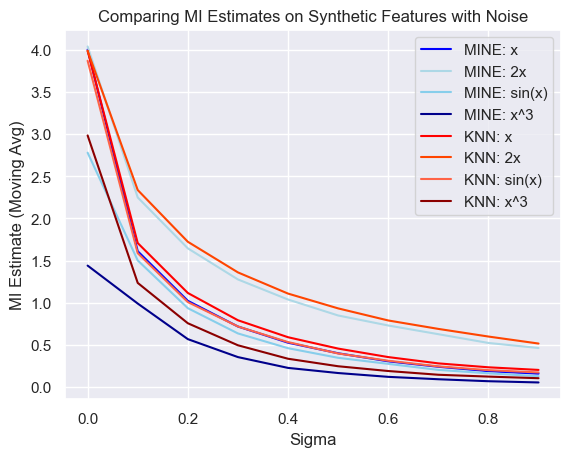

In [ ]:
colors_MINE = ['blue', 'lightblue', 'skyblue', 'darkblue']
colors_KNN = ['red', 'orangered', 'tomato', 'darkred']
# Comparing both now
for fi, f in enumerate(fs):
    plt.plot(sigmas, synthetic_MI_MINE[fi], color = colors_MINE[fi], label = "MINE: " + synth_labels[fi])
for fi, f in enumerate(fs):
    plt.plot(sigmas, synthetic_MI_KNN[fi], color = colors_KNN[fi], label = "KNN: " + synth_labels[fi])

plt.xlabel("Sigma")
plt.ylabel("MI Estimate (Moving Avg)")
plt.title("Comparing MI Estimates on Synthetic Features with Noise")
plt.legend()
plt.show()

# Results: MINE

In [ ]:
# Now we can start testing with out EEG Data!
result_joint_MINE = []
for i in range(num_eeg_files):
    # Here we are going to initialize our MINE model with out CPU
    mine_net_indep = Mine().to('cpu')
    # This one on the other hand, is a different model, as it updates our old one with a different learning rate of 1e-3
    mine_net_optim_indep = optim.Adam(mine_net_indep.parameters(), lr = 1e-3)

    # Here we normalize our sample to make sure we prevent near-zero division
    sample = (data_mine[i] - data_mine[i].mean(axis=0)) / (data_mine[i].std(axis=0) + 1e-8)
    
    # With this information now, the train function is called. This performs that actual training of our MINE model using the data and optimizer
    # After the training, the results (our MI estimates) are appeneded to a list for data gathering
    trained_MINE_sample = [calculated_ma.item() for calculated_ma in train_MINE(sample, i, mine_net_indep, mine_net_optim_indep)]
    #print(trained_MINE_sample)
    result_joint_MINE.append(trained_MINE_sample)

Results from EEG File #1: 0.22585283522494137
Results from EEG File #2: 0.26931213433854284
Results from EEG File #3: 0.21726654805243015


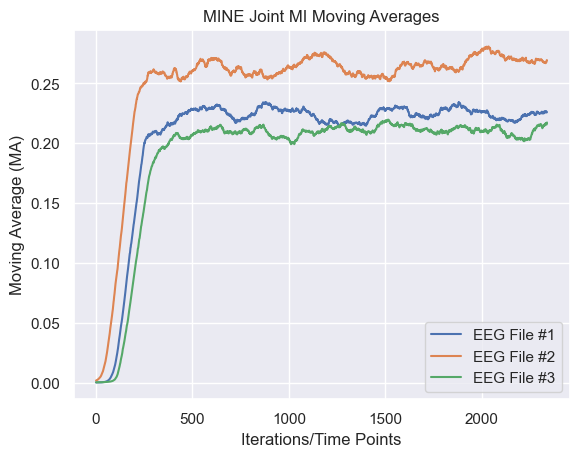

In [ ]:
# Plotting out our results the calculated Moving Averages of our MINE results from our joint dataset
for i in range(num_eeg_files):
    # This is our Moving Average calculation here. Smoothing out our data as we graph it
    result_joint_MINE_ma = calculate_moving_average(result_joint_MINE[i])
    print("Results from EEG File #" + str(i + 1) + ": " + str(result_joint_MINE_ma[-1]))
    plt.plot(range(len(result_joint_MINE_ma)), result_joint_MINE_ma, label = "EEG File #" + str(i + 1))

# print(result_joint_MINE_ma)
plt.title("MINE Joint MI Moving Averages")
plt.xlabel("Iterations/Time Points")  # X-axis label
plt.ylabel("Moving Average (MA)")  # Y-axis label
# plt.ylim(0.20, 0.29)
plt.legend()
plt.show()

# Results: kNN

In [ ]:
# Store raw kNN MI values for each EEG file
result_joint_KNN_MI = []

# Training each of our random data sets in our EEG files
for i in range(num_eeg_files):
    # Training our kNN Sample(s)
    # Normalizing the data here as well
    sample = (data_knn[i] - data_knn[i].mean(axis=0)) / (data_knn[i].std(axis=0) + 1e-8)
    trained_KNN_sample = train_KNN_MI(sample, batch_size = 300)
    # print(trained_KNN_sample)
    result_joint_KNN_MI.append(trained_KNN_sample)

Results from EEG File #1: 0.24313748189423984
Results from EEG File #2: 0.2711180214773564
Results from EEG File #3: 0.23020099488275436


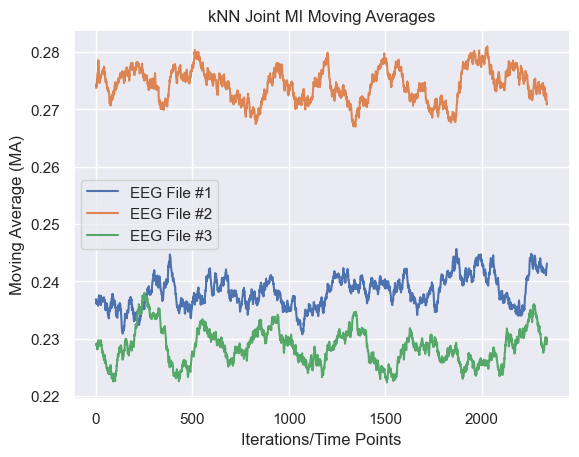

In [ ]:
result_joint_KNN_MI_ma = []

# Plotting our graph of Moving Averages for our kNN Model
for i in range(num_eeg_files):
    result_joint_KNN_MI_ma.append(calculate_moving_average(result_joint_KNN_MI[i]))
    print("Results from EEG File #" + str(i + 1) + ": " + str(result_joint_KNN_MI_ma[i][-1]))
    plt.plot(range(len(result_joint_KNN_MI_ma[i])), result_joint_KNN_MI_ma[i], label = f"EEG File #{i + 1}")

plt.title("kNN Joint MI Moving Averages")
plt.xlabel("Iterations/Time Points")  # X-axis label
plt.ylabel("Moving Average (MA)")  # Y-axis label
# plt.ylim(0.20, 0.29)
plt.legend()
plt.show()

# Comparison: Correlation and Mutual Information

We now compare mutual information estimates from both the kNN and MINE models across varying levels of correlation. The key idea is that **mutual information (MI)** quantifies the amount of dependency between two variables — regardless of whether that relationship is linear or nonlinear.

In theory:
- **High correlation** (positive or negative) → high dependency → **higher MI**.
- **No correlation (≈ 0)** → no linear dependency → **MI should approach 0**, assuming independence.

This matters because EEG signals from two different channels may be **highly correlated** if they’re capturing synchronized neural activity, such as functionally connected brain regions.

### Understanding Correlation Types:
- **Positive Correlation**: Both variables increase or decrease together. Higher correlation → stronger alignment → higher MI.
- **Negative Correlation**: One variable increases as the other decreases. Again, stronger correlation → stronger (inverse) dependency → higher MI.
- **Zero Correlation**: No clear linear relationship. This suggests independence and should result in **low MI values**.

### Why this matters:
Tracking how MI responds to varying correlation levels helps us evaluate how well MINE and kNN capture **signal dependencies** in EEG data. A model that continues reporting high MI at zero correlation likely fails to distinguish between dependent and independent structures.

Ultimately, this test helps validate the **sensitivity and reliability** of MINE as an estimator of brain signal dependency — especially in comparison to traditional kNN methods.

In [ ]:
# Here, We create an array of correlation values for testing
# Our values will be ranging from -0.9 to 0.9 with 19 evenly spaced values
correlations = np.linspace(-0.9, 0.9, 19)
print(correlations)
# The generated correlation values will be used in subsequent steps for testing how the MINE model performs
# More specifically, how it performs under different levels of correlation between the data
# The data we will be using will be our first EEG dataset
batch = sample_batch(data_mine[0], batch_size = 300, sample_mode = 'marginal')

[-0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0.   0.1  0.2  0.3  0.4
  0.5  0.6  0.7  0.8  0.9]


[np.float32(0.74237764), np.float32(0.42339864), np.float32(0.31441465), np.float32(0.2287271), np.float32(0.14308877), np.float32(0.061597623), np.float32(0.044617407), np.float32(0.01550893), np.float32(3.527741e-05), np.float32(7.209539e-05), np.float32(2.662267e-06), np.float32(0.0064946623), np.float32(0.047319926), np.float32(0.07837285), np.float32(0.13124199), np.float32(0.26333672), np.float32(0.3078301), np.float32(0.40173215), np.float32(0.81604004)]


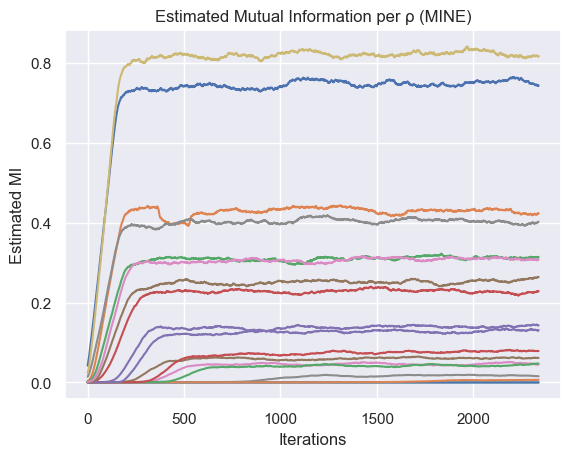

In [ ]:
correlated_MI_MINE = []
# Here, we will evaluate our MINE model by testing it across our correlated data with different correlation levels
# We will go through all 19 correlation levels
for rho in correlations:
    '''
    The mean is a coordinate in N-dimensional space, which represents the location where samples are most likely to be generated. 
    This is analogous to the peak of the bell curve for the one-dimensional or univariate normal distribution.

    Covariance indicates the level to which two variables vary together. From the multivariate normal distribution, we draw N-dimensional samples, X = [x1, x2, ..., xN]
        . The covariance matrix element C_ij is the covariance of x_i and x_j
        . The element C_ii is the variance of x_i (i.e. its “spread”).
    '''
    mean = np.mean(batch, axis=0)
    cov = [[1, rho], [rho, 1]]
    size = 300

    rho_data = np.random.multivariate_normal(mean, cov, size)
    
    # Once again, we will create our new instance of MINE and the Optimizer instance
    # With these, we will...
    mine_net = Mine().to('cpu')
    mine_net_optim = optim.Adam(mine_net.parameters(), lr = 1e-3)
    
    # Now we train the MINE model on our new, synthetic data
    result = train_MINE(rho_data, -1, mine_net, mine_net_optim, batch_size = 300)
    result_ma_MINE = calculate_moving_average(result)

    # We store the last value of our Moving Average
    correlated_MI_MINE.append(result_ma_MINE[-1])
    # print(str(round(rho, 1)) + ' : ' + str(correlated_MI_MINE[-1]))
    plt.plot(range(len(result_ma_MINE)), result_ma_MINE, label=str(rho) + " Frequency")

print(correlated_MI_MINE)
plt.title("Estimated Mutual Information per ρ (MINE)")
plt.xlabel("Iterations")
plt.ylabel("Estimated MI")
plt.show()

[np.float64(0.939842570181475), np.float64(0.6324733433087889), np.float64(0.47088205402315475), np.float64(0.35137047642387975), np.float64(0.15845236069467455), np.float64(0.19722682839479674), np.float64(0.1560595638410489), np.float64(0.11209360813213225), np.float64(0.06914672841676857), np.float64(0.1212301218386435), np.float64(0.08210278246800275), np.float64(0.11408663993294907), np.float64(0.12917374168272536), np.float64(0.17368013693129442), np.float64(0.239359904048767), np.float64(0.3175897216763287), np.float64(0.4114614649690466), np.float64(0.60538131952714), np.float64(0.8272107726669924)]


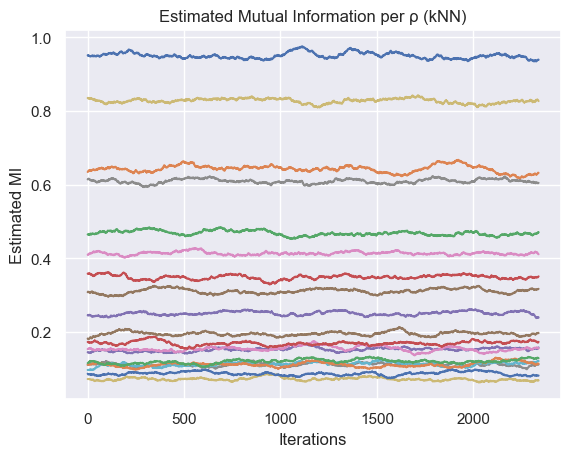

In [ ]:
correlated_MI_KNN = []

# For each correlation value rho...
for rho in correlations:
    mean = np.mean(batch, axis=0)
    cov = [[1, rho], [rho, 1]]
    size = 300

    rho_data = np.random.multivariate_normal(mean, cov, size);
    
    # Train kNN estimator over synthetic data
    result = train_KNN_MI(rho_data, batch_size = 150)
    result_ma_KNN = calculate_moving_average(result)

    # Save the last moving average value
    correlated_MI_KNN.append(result_ma_KNN[-1])

    # Plot each MI curve per rho
    plt.plot(range(len(result_ma_KNN)), result_ma_KNN, label=f"ρ = {rho}")

print(correlated_MI_KNN)
plt.title("Estimated Mutual Information per ρ (kNN)")
plt.xlabel("Iterations")
plt.ylabel("Estimated MI")
plt.show()

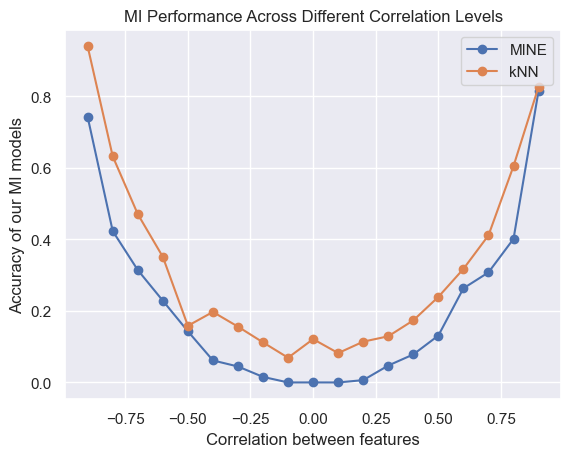

In [ ]:
# Comparing the correlated Graphs as well
plt.plot(correlations, correlated_MI_MINE, marker='o', linestyle='-', label='MINE')
plt.plot(correlations, correlated_MI_KNN, marker='o', linestyle='-', label='kNN')
plt.xlabel('Correlation between features')
plt.ylabel('Accuracy of our MI models')
plt.title('MI Performance Across Different Correlation Levels')
plt.legend()
plt.show()

# Conclusion

What does this mean for MINE and kNN based on our results?

### MINE:
- **Strengths**:
  - Capable of detecting **strong nonlinear dependencies** when signal quality is high.
  - Shows good performance at **very high correlation values**, where relationships are clearly defined.
  - Designed for **flexible, high-dimensional modeling**, making it a potentially powerful tool in deep learning contexts.

- **Weaknesses**:
  - **Underperforms compared to kNN** across (most often) all correlation levels, and always at low or moderate correlations.
  - More **sensitive to noise and continuous variance**, leading to unstable or low mutual information estimates.
  - May require extensive **preprocessing (e.g., normalization, smoothing)** to produce stable results.

### kNN (mutual_info_regression):
- **Strengths**:
  - Provides **more accurate and stable MI estimates** across a wide spectrum of correlation values.
  - Particularly effective even when **correlation approaches 0**, where MINE struggles the most.
  - Offers **robustness without needing intensive tuning**, making it a strong choice for quick, interpretable analysis.

- **Weaknesses**:
  - Less adaptive to **complex nonlinear structures** — though still adequate in practical EEG contexts.
  - May be limited in higher-dimensional spaces without careful parameter tuning.

### Final Takeaway:
- While **MINE is more flexible** in theory, in practice (with noisy EEG data and synthetic tests), **kNN consistently provides stronger and more interpretable MI estimates**.
- This suggests that **traditional methods like kNN remain competitive**, especially when working with real-world continuous signals.
- Moving forward, **refining MINE’s preprocessing pipeline or architecture** may help it close the gap — but for now, **kNN proves to be the more reliable estimator** under these conditions.